In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("customer_booking.csv", encoding="latin1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [7]:
df.shape

(50000, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [9]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [10]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [11]:
df["booking_complete"].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

## Dataset Summary

- The dataset contains **50,000 customer booking records** and **14 variables**.
- There are **8 numerical features**, **5 categorical features**, and **1 target variable (`booking_complete`)**.
- No missing values were found in the dataset, so no imputation is required.
- The target variable (`booking_complete`) is binary:
  - 0 = Booking not completed
  - 1 = Booking completed

In [13]:
df['booking_complete'].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

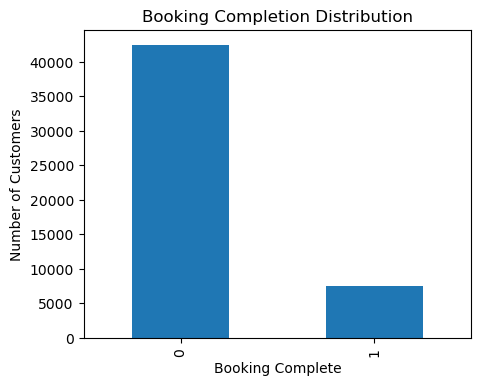

In [14]:
df['booking_complete'].value_counts().plot(
    kind='bar',
    figsize=(5,4)
)

plt.title("Booking Completion Distribution")
plt.xlabel("Booking Complete")
plt.ylabel("Number of Customers")
plt.show()

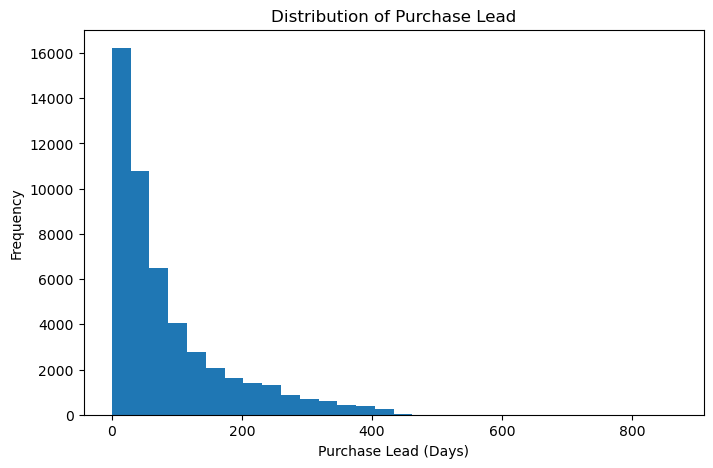

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df['purchase_lead'], bins=30)

plt.title("Distribution of Purchase Lead")
plt.xlabel("Purchase Lead (Days)")
plt.ylabel("Frequency")

plt.show()

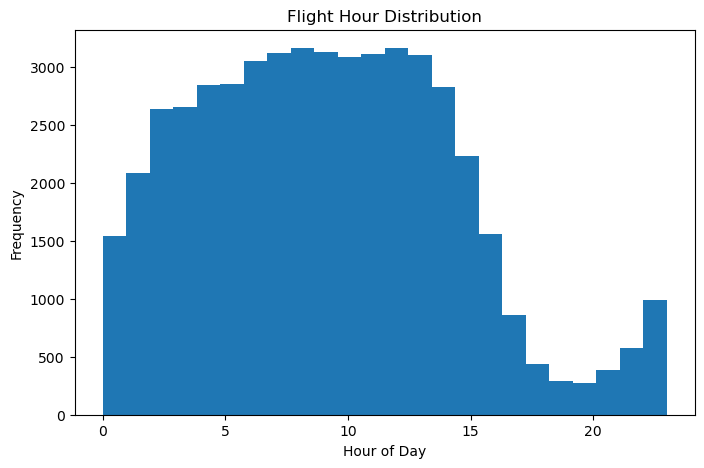

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df['flight_hour'], bins=24)

plt.title("Flight Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")

plt.show()

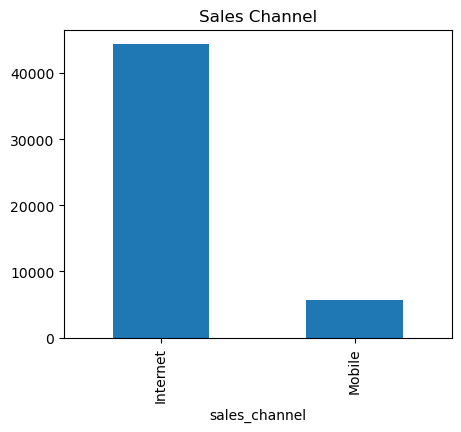

In [17]:
df['sales_channel'].value_counts().plot(
    kind='bar',
    figsize=(5,4)
)

plt.title("Sales Channel")
plt.show()

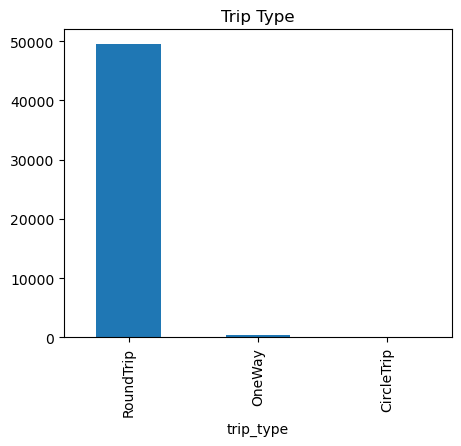

In [18]:
df['trip_type'].value_counts().plot(
    kind='bar',
    figsize=(5,4)
)

plt.title("Trip Type")
plt.show()

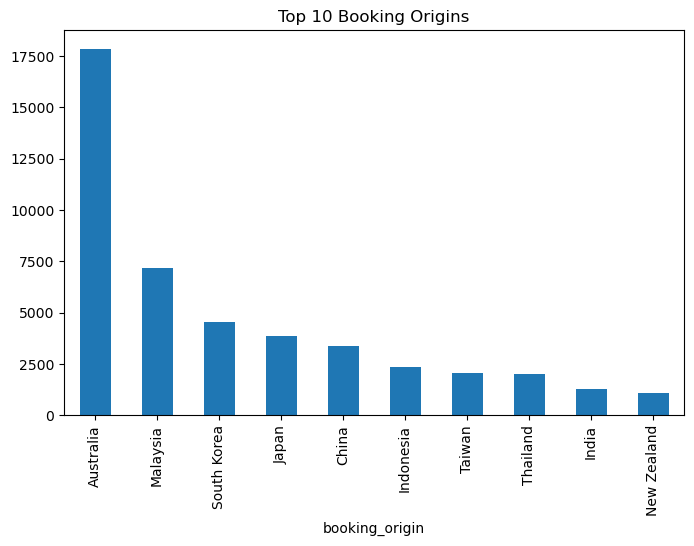

In [19]:
df['booking_origin'].value_counts().head(10).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 10 Booking Origins")

plt.show()

## Exploratory Data Analysis Summary

- The dataset contains 50,000 customer booking records with no missing values.
- The target variable (`booking_complete`) is imbalanced, with far more incomplete bookings than completed bookings.
- Purchase lead is positively skewed, indicating that most customers book closer to their departure date.
- Most flights depart during daytime hours, particularly between morning and afternoon.
- The Internet is the primary sales channel, while mobile bookings represent a much smaller share.
- Round-trip bookings dominate the dataset, with very few one-way or circle trips.
- Australia accounts for the highest number of bookings, followed by Malaysia, South Korea, Japan, and China.

In [20]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Mobile,...,booking_origin_Timor-Leste,booking_origin_Tonga,booking_origin_Tunisia,booking_origin_Turkey,booking_origin_Ukraine,booking_origin_United Arab Emirates,booking_origin_United Kingdom,booking_origin_United States,booking_origin_Vanuatu,booking_origin_Vietnam
0,2,262,19,7,1,0,0,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
1,1,112,20,3,0,0,0,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
2,2,243,22,17,1,1,0,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
3,1,96,31,4,0,0,1,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False
4,2,68,22,15,1,0,1,5.52,0,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
X = df_encoded.drop('booking_complete', axis=1)

y = df_encoded['booking_complete']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (50000, 918)
Target Shape: (50000,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(40000, 918)
(10000, 918)


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
y_pred = rf_model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8543


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      8504
           1       0.56      0.12      0.20      1496

    accuracy                           0.85     10000
   macro avg       0.71      0.55      0.56     10000
weighted avg       0.82      0.85      0.81     10000



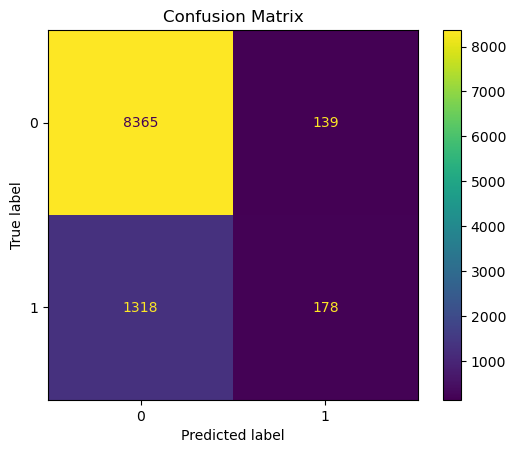

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")
plt.show()

In [36]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.8497 0.7815 0.7255 0.5396 0.7818]
Average Accuracy: 0.73562


In [37]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,purchase_lead,0.149618
3,flight_hour,0.123729
2,length_of_stay,0.111554
0,num_passengers,0.048280
7,flight_duration,0.036566
865,booking_origin_Malaysia,0.027485
6,wants_in_flight_meals,0.024493
818,booking_origin_Australia,0.019630
5,wants_preferred_seat,0.017962
4,wants_extra_baggage,0.017654


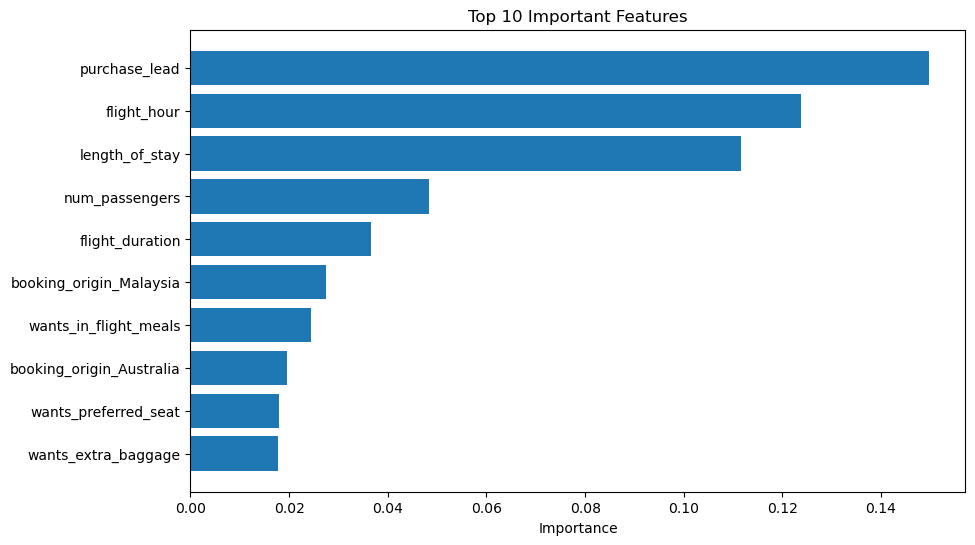

In [38]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()